# Machine Learning Foundation

## Course 3, Part b: K-Nearest Neighbor LAB


### K-Nearest Neighbors (KNN)

The KNN is another model algorithm we can use to predict output classification based on its data features just as we had seen in Logistic Regression. The mechanism involve, however, is very different. KNN uses the next closest target label to decide on its prediction outcome. For example, in the following diagram, if we want to predict if a customer will churn with a target label based on the data and phone usage (the purple dot), the algorithm will predict based on the nearest neightbor label target/s. If the neighbor is a True (Churn), then the predicted result will also be True. 

<img src="images/KNN/KNN_Classification.png" width="50%">

The key to the neighbor's selection is also dependant to K value, which is the number of neighbors to use for basing its prediction by consensus. For example, if K=4, then 4 neighbors will be selected as a basis in deciding the prediction. To avoid tie, an odd value is usually used for the value of K. 

### What is needed for KNN selection process?

As previously illustrated, a good/correct value for K will help to avoid tie and also improve its prediction accuracy. Another requirement that would help is the closeness of the neighbors from the targeted data point.

<img src="images/KNN/KNN_requirement.png" width="50%">

For the K value, if we start off at K=1, we can see that every decision will follow the Training data set, resulting in Overfitting.

<img src="images/KNN/KNN_Overfitted.png" width="50%">

The other extreme is to use K=all, and this will result in over generalization, or Underfitted.

<img src="images/KNN/KNN_Underfitted.png" width="50%">

So how to choose an optimal value for K? In instantiating a KNN model object, we need to specify the value of K. 

<img src="images/KNN/KNN_ChoosingRightValueOfK.png" width="50%">

The model will not provide a K value as we seen in regularization in Logistic Regression. The right value will depends on which error metric is most relevant to the problem objective. We can use the F1 score to help us. 

<img src="images/KNN/KNN_f1.png" width="50%">

A common approach is to use the 'elbow method'.

<img src="images/KNN/KNN_elbow.png" width="50%">





### Calculating the K distance

As we can see we will also need to calculate the distance to measure the closeness to the target's neighbors. There are two ways to compute the neighbor's distance. The first is called the **Euclidean Distance - L1**. This is based on pythygorous theorem as shown in the following diagram.

<img src="images/KNN/KNN_EuclideanDistance(L2).png" width="50%">

The other method is **Manhattan Distance - L1**. This is based on absolute distance and can be seen visually in the following diagram.

<img src="images/KNN/KNN_ManhattanDistance(L1).png" width="50%">


### Feature Scaling

Given that the algorithm is based on distance of neighbors, which reflects the feature's units, it is critical that the features are properly scaled so that target labels are not lump close to each other.

<img src="images/KNN/KNN_FeatureScaling.png" width="50%">




### Regression with KNN

Note that the KNN can also be used for Regression analysis where the target labels are continuous instead of classes. Instead of using its neighbor's classification as prediction result, here we uses the mean value of the neighbors.

<img src="images/KNN/KNN_forRegression.png" width="50%">



### Pros and Cons of KNN

<img src="images/KNN/KNN_ProsAndCons.png" width="50%">

### Characteristics of KNN vs Linear Regression

<img src="images/KNN/KNN_vs_LinearRegression.png" width="50%">

###

___

## Lab Introduction and Learning Goals

In this lab, we will explore classification using the K-Nearest Neighbors approach. We will use a customer churn dataset from the telecom industry, which includes customer data such as long-distance usage, data usage, monthly revenue, types of offerings, and other services purchased by customers. The data, based on a fictional telecom firm, includes several Excel files which have been combined and are available in the course materials. We are using the subset of customers who have phone accounts. Since the data includes a mix of numeric, categorical, and ordinal variables, we will load this data and do some preprocessing. Then we will use K-nearest neighbors to predict customer churn rates.

After completing this lab, you should have a working understanding of how to preprocess a variety of variables to apply the K-Nearest Neighbors algorithm, understand how to choose K, and understand how to evaluate model performance.


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

## Question 1

* We begin by importing the data. Examine the columns and data.
* Notice that the data contains a unique ID, an indicator for phone customer status, total lifetime value, total revenue, and a bank-estimated churn score. We will not be using these features, so they can be dropped from the data.
* Begin by taking an initial look at the data, including both numeric and non-numeric features.


In [2]:
# data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/churndata_processed.csv"

df = pd.read_csv("data/churndata_processed.csv")
df.head()

,months,multiple,gb_mon,security,backup,protection,support,unlimited,contract,paperless,...,payment_Credit Card,payment_Mailed Check,internet_type_DSL,internet_type_Fiber Optic,internet_type_None,offer_Offer A,offer_Offer B,offer_Offer C,offer_Offer D,offer_Offer E
0,0.00,0,0.094118,0,0,1,0,0,0.0,1,...,0,0,1,0,0,0,0,0,0,0
1,0.00,1,0.200000,0,1,0,0,1,0.0,1,...,1,0,0,1,0,0,0,0,0,1
2,0.25,1,0.611765,0,0,0,0,1,0.0,1,...,0,0,0,1,0,0,0,0,1,0
3,0.25,0,0.141176,0,1,1,0,1,0.0,1,...,0,0,0,1,0,0,0,1,0,0
4,0.50,1,0.164706,0,0,0,0,1,0.0,1,...,0,0,0,1,0,0,0,1,0,0


In [3]:
round(df.describe(),2)

,months,multiple,gb_mon,security,backup,protection,support,unlimited,contract,paperless,...,payment_Credit Card,payment_Mailed Check,internet_type_DSL,internet_type_Fiber Optic,internet_type_None,offer_Offer A,offer_Offer B,offer_Offer C,offer_Offer D,offer_Offer E
count,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,...,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00,7043.00
mean,0.43,0.42,0.24,0.29,0.34,0.34,0.29,0.67,0.38,0.59,...,0.39,0.05,0.23,0.43,0.22,0.07,0.12,0.06,0.09,0.11
std,0.40,0.49,0.24,0.45,0.48,0.48,0.45,0.47,0.42,0.49,...,0.49,0.23,0.42,0.50,0.41,0.26,0.32,0.24,0.28,0.32
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.25,0.00,0.20,0.00,0.00,0.00,0.00,1.00,0.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.75,1.00,0.32,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [4]:
df.dtypes.value_counts()

int64      18
float64     5
Name: count, dtype: int64

## Question 2

* Identify which variables are binary, categorical and not ordinal, categorical and ordinal, and numeric.  The non-numeric features will need to be encoded using methods we have discussed in the course.
* Start by identifying the number of unique values each variable takes, then create list variables for categorical, numeric, binary, and ordinal variables. 
* Note that the variable 'months' can be treated as numeric, but it may be more convenient to transform it to an ordinal variable.
* For the other categorical variables, examine their values to determine which may be encoded ordinally.


In [5]:
df_uniques = pd.DataFrame([[i, len(df[i].unique())] for i in df.columns], columns=['Variable', 'Unique Values']).set_index('Variable')
df_uniques

,Unique Values
Variable,
months,5
multiple,2
gb_mon,50
security,2
backup,2
protection,2
support,2
unlimited,2
contract,3


In [6]:
binary_variables = list(df_uniques[df_uniques['Unique Values'] == 2].index)
binary_variables

['multiple',
 'security',
 'backup',
 'protection',
 'support',
 'unlimited',
 'paperless',
 'churn_value',
 'payment_Credit Card',
 'payment_Mailed Check',
 'internet_type_DSL',
 'internet_type_Fiber Optic',
 'internet_type_None',
 'offer_Offer A',
 'offer_Offer B',
 'offer_Offer C',
 'offer_Offer D',
 'offer_Offer E']

In [7]:
categorical_variables = list(df_uniques[(6 >= df_uniques['Unique Values']) & (df_uniques['Unique Values'] > 2)].index)
categorical_variables

['months', 'contract', 'satisfaction']

In [8]:
[[i, list(df[i].unique())] for i in categorical_variables]

[['months',
  [np.float64(0.0),
   np.float64(0.25),
   np.float64(0.5),
   np.float64(1.0),
   np.float64(0.75)]],
 ['contract', [np.float64(0.0), np.float64(0.5), np.float64(1.0)]],
 ['satisfaction',
  [np.float64(0.5),
   np.float64(0.25),
   np.float64(0.0),
   np.float64(0.75),
   np.float64(1.0)]]]

In [9]:
ordinal_variables = ['contract', 'satisfaction']

In [10]:
df['months'].unique()

array([0.  , 0.25, 0.5 , 1.  , 0.75])

In [11]:
ordinal_variables.append('months')

In [12]:
numeric_variables = list(set(df.columns) - set(ordinal_variables) - set(categorical_variables) - set(binary_variables))

array([[<Axes: title={'center': 'monthly'}>,
        <Axes: title={'center': 'gb_mon'}>]], dtype=object)

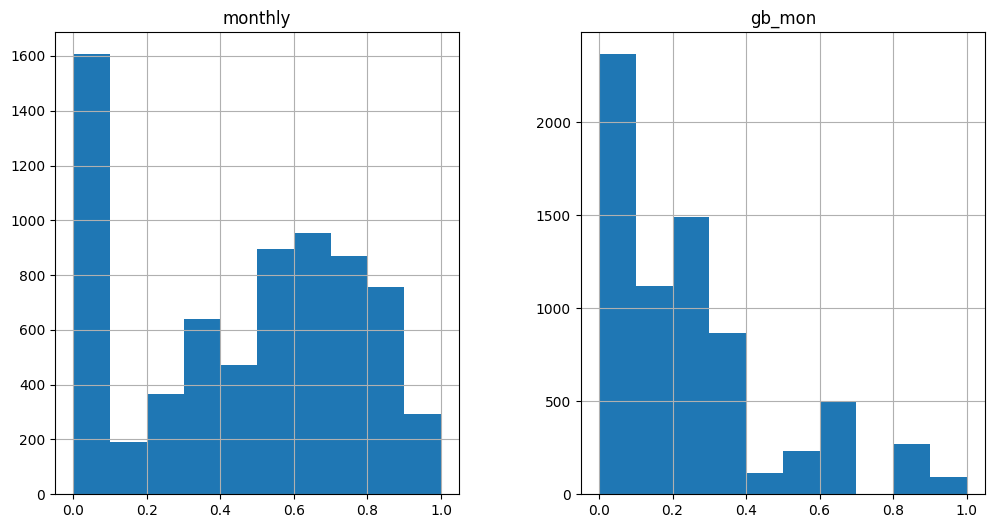

In [13]:
df[numeric_variables].hist(figsize=(12, 6))

In [14]:
df['months'] = pd.cut(df['months'], bins=5)

## Question 3
* Having set up the variables, remember that the K-nearest neighbors algorithm uses distance and hence requires scaled data. 
* Save the processed dataframe as a comma-separated file: 'churndata_encoded.csv'




In [15]:
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, OrdinalEncoder

In [16]:
lb, le = LabelBinarizer(), LabelEncoder()

In [17]:
for column in ordinal_variables:
    df[column] = le.fit_transform(df[column])

In [18]:
df[ordinal_variables].astype('category').describe()

,contract,satisfaction,months
count,7043,7043,7043
unique,3,5,5
top,0,2,0
freq,3610,2665,2470


In [19]:
for column in binary_variables:
    df[column] = lb.fit_transform(df[column])

In [20]:
categorical_variables = list(set(categorical_variables) - set(ordinal_variables))

In [21]:
df = pd.get_dummies(df, columns = categorical_variables, drop_first=True)

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
months,7043.0,1.734204,1.592924,0.0,0.000000,1.000000,3.000000,4.0
multiple,7043.0,0.421837,0.493888,0.0,0.000000,0.000000,1.000000,1.0
gb_mon,7043.0,0.241358,0.240223,0.0,0.035294,0.200000,0.317647,1.0
security,7043.0,0.286668,0.452237,0.0,0.000000,0.000000,1.000000,1.0
backup,7043.0,0.344881,0.475363,0.0,0.000000,0.000000,1.000000,1.0
protection,7043.0,0.343888,0.475038,0.0,0.000000,0.000000,1.000000,1.0
support,7043.0,0.290217,0.453895,0.0,0.000000,0.000000,1.000000,1.0
unlimited,7043.0,0.673719,0.468885,0.0,0.000000,1.000000,1.000000,1.0
contract,7043.0,0.754792,0.848468,0.0,0.000000,0.000000,2.000000,2.0
paperless,7043.0,0.592219,0.491457,0.0,0.000000,1.000000,1.000000,1.0


In [23]:
# Save a copy of the encodeded data for later use
# outputfile = 'data/churndata_encoded.csv'
# df.to_csv(outputfile, index=False)

## Question 4
* Split the sample into training and test samples, with the test sample representing 40% of observations.
* Scale the data using one of the scaling methods discussed in the course.
* Estimate a K-Nearest Neighbors model, using K=3.
* Examine the Precision, Recall, F-1 Score, and Accuracy of the classification.
* Use a graphic to illustrate the Confusion Matrix. 

As discussed in Logistic Regression, we must split the data into Training and Testing dataset before scaling to avoid data leakages.

In [24]:
from sklearn.model_selection import train_test_split

# 1. Set up X and y variables FIRST
y, X = df['churn_value'], df.drop(columns='churn_value')

# 2. Split the data into training and test samples BEFORE scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Define columns that need scaling
columns_to_scale = ordinal_variables + numeric_variables

round(df.describe().T, 3)

,count,mean,std,min,25%,50%,75%,max
months,7043.0,1.734,1.593,0.0,0.000,1.000,3.000,4.0
multiple,7043.0,0.422,0.494,0.0,0.000,0.000,1.000,1.0
gb_mon,7043.0,0.241,0.240,0.0,0.035,0.200,0.318,1.0
security,7043.0,0.287,0.452,0.0,0.000,0.000,1.000,1.0
backup,7043.0,0.345,0.475,0.0,0.000,0.000,1.000,1.0
protection,7043.0,0.344,0.475,0.0,0.000,0.000,1.000,1.0
support,7043.0,0.290,0.454,0.0,0.000,0.000,1.000,1.0
unlimited,7043.0,0.674,0.469,0.0,0.000,1.000,1.000,1.0
contract,7043.0,0.755,0.848,0.0,0.000,0.000,2.000,2.0
paperless,7043.0,0.592,0.491,0.0,0.000,1.000,1.000,1.0


Now, we are ready to scale the data features.

In [25]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()

# Fit ONLY on training data and transform it
X_train[columns_to_scale] = mm.fit_transform(X_train[columns_to_scale])

# Transform test data using the training data's scale parameters
X_test[columns_to_scale] = mm.transform(X_test[columns_to_scale])

Estimate a K-Nearest Neighbors model with K=3

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score

# Estimate KNN model and report outcomes
knn = KNeighborsClassifier(n_neighbors=3)
knn = knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Preciision, recall, f-score from the multi-class support function
print(classification_report(y_test, y_pred))
print('Accuracy score: ', round(accuracy_score(y_test, y_pred), 2))
print('F1 Score: ', round(f1_score(y_test, y_pred), 2))

              precision    recall  f1-score   support

           0       0.90      0.92      0.91      2048
           1       0.77      0.72      0.74       770

    accuracy                           0.86      2818
   macro avg       0.83      0.82      0.82      2818
weighted avg       0.86      0.86      0.86      2818

Accuracy score:  0.86
F1 Score:  0.74


[]

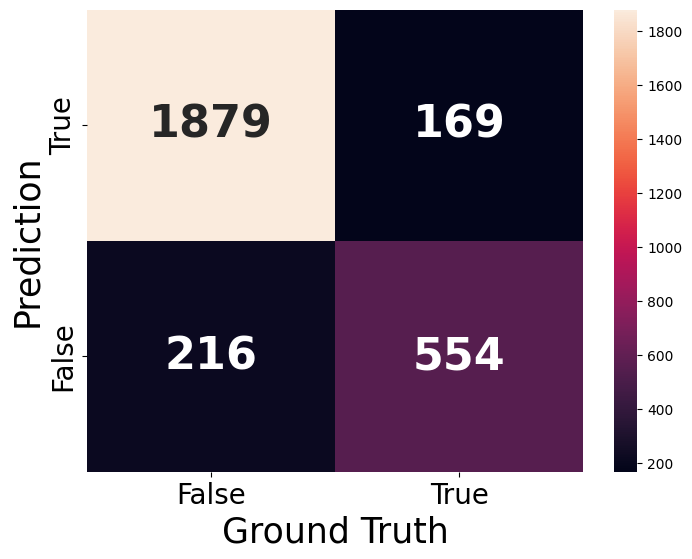

In [ ]:
# Plot confusion matrix
sns.set_palette(sns.color_palette())
_, ax = plt.subplots(figsize=(8,6))
ax = sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', annot_kws={"size": 32, "weight": "bold"})  
labels = ['False', 'True'] #['Not Churn', 'Churn']????
ax.set_xticklabels(labels, fontsize=20);
ax.set_yticklabels(labels[::-1], fontsize=20);
ax.set_ylabel('Prediction', fontsize=25);
ax.set_xlabel('Ground Truth', fontsize=25)
ax.plot()


## Question 5
* Using the same split of training and test samples, estimate another K-Nearest Neighbors model.
* This time, use K=5 and weight the results by distance.
* Again, examine the Precision, Recall, F-1 Score, and Accuracy of the classification, and visualize the Confusion Matrix. 


In [28]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn = knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Preciision, recall, f-score from the multi-class support function
print(classification_report(y_test, y_pred))
print('Accuracy score: ', round(accuracy_score(y_test, y_pred), 2))
print('F1 Score: ', round(f1_score(y_test, y_pred), 2))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91      2048
           1       0.78      0.74      0.76       770

    accuracy                           0.87      2818
   macro avg       0.84      0.83      0.84      2818
weighted avg       0.87      0.87      0.87      2818

Accuracy score:  0.87
F1 Score:  0.76


[]

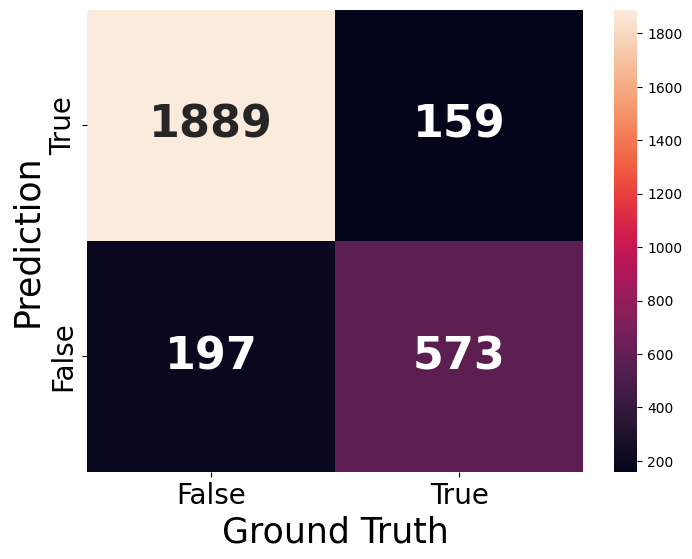

In [29]:
# Plot confusion matrix
sns.set_palette(sns.color_palette())
_, ax = plt.subplots(figsize=(8,6))
ax = sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', annot_kws={"size": 32, "weight": "bold"})  
labels = ['False', 'True']
ax.set_xticklabels(labels, fontsize=20);
ax.set_yticklabels(labels[::-1], fontsize=20);
ax.set_ylabel('Prediction', fontsize=25);
ax.set_xlabel('Ground Truth', fontsize=25)
ax.plot()


## Question 6
* To determine the right value for K, examine results for values of K from 1 to 40.
* This time, focus on two measures, the F-1 Score, and the Error Rate (1-Accuracy).
* Generate charts which plot each of these measures as a function of K. 
* What do these charts suggest about the optimal value for K?


In [30]:
max_k = 40
f1_scores = list()
error_rates = list() # 1-accuracy

for k in range(1, max_k):
    
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn = knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    f1 = f1_score(y_pred, y_test)
    f1_scores.append((k, round(f1_score(y_test, y_pred), 4)))
    error = 1 - round(accuracy_score(y_test, y_pred), 4)
    error_rates.append((k, error))
    
f1_results = pd.DataFrame(f1_scores, columns=['K', 'F1 Score'])
error_results = pd.DataFrame(error_rates, columns=['K', 'Error Rate'])

<Figure size 1920x1440 with 0 Axes>

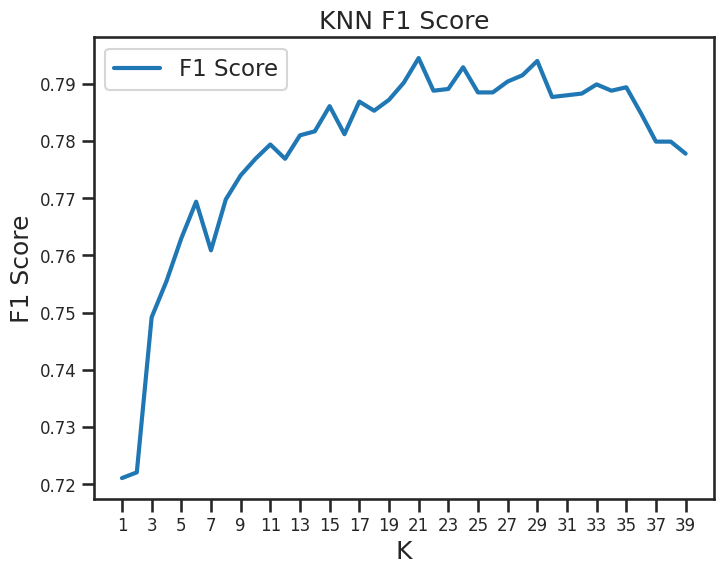

In [31]:
# Plot F1 results
sns.set_context('talk')
sns.set_style('ticks')

plt.figure(dpi=300)
ax = f1_results.set_index('K').plot(figsize=(8, 6), linewidth=3)
ax.set(xlabel='K', ylabel='F1 Score')
ax.set_xticks(range(1, max_k, 2))
ax.tick_params(axis='both', labelsize=12)
plt.title('KNN F1 Score')
plt.savefig('knn_f1.png')

<Figure size 1920x1440 with 0 Axes>

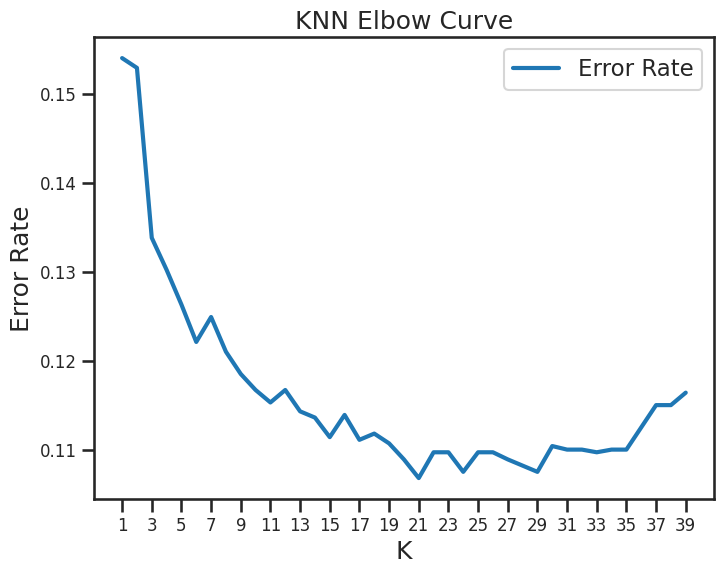

In [32]:
# Plot Accuracy (Error Rate) results
sns.set_context('talk')
sns.set_style('ticks')

plt.figure(dpi=300)
ax = error_results.set_index('K').plot(figsize=(8, 6), linewidth=3)
ax.set(xlabel='K', ylabel='Error Rate')
ax.set_xticks(range(1, max_k, 2))
ax.tick_params(axis='both', labelsize=12)
plt.title('KNN Elbow Curve')
plt.savefig('knn_elbow.png')


### Optimal K value from the above F1 Score and Elbow Curve

Based on both charts, $K = 21$ is indeed the optimal choice. Here is exactly why the inference is correct, looking at how the two metrics mirror each other perfectly:

1. The Elbow Curve (Error Rate)
* The Goal: We want to minimize the error rate.
* The Finding: The curve hits its absolute lowest point right at $K = 21$, where the error rate drops just below $0.11$ (around $0.107$).
* The Context: After $K = 21$, the error rate begins to trend upward again, which signifies that the model is starting to underfit (becoming too simple and smoothing over local patterns).

2. The F1 Score Curve
* The Goal: We want to maximize the F1 Score (balancing precision and recall).
* The Finding: As expected, the peak of this curve occurs precisely at $K = 21$, pushing the F1 score to its maximum value of nearly $0.795$.
* The Context: Just like the error curve, performance degrades after this peak.

While $K = 21$ is mathematically optimal here, it is generally good practice in binary classification (like our churn_value which uses True/False or 1/0) to choose an odd number for $K$ to prevent tie votes. Since $21$ is already odd, it's structurally perfect!


We can also derived the optimal K value programatically as shown below:

In [33]:
optimal_k = f1_results[f1_results['F1 Score'] == f1_results['F1 Score'].max()]['K'].values
print(f"The optimal K value is: {optimal_k}")

# f1_results.sort_values('F1 Score', ascending=False)

The optimal K value is: [21]


### How to select optimal K when there are multiple peak F1 Scores?

It is possible to have two (or more) peak values for the F1 Score! 

Because the KNN algorithm depends entirely on the local density of data points around a query, the addition or subtraction of neighbors as $K$ changes can cause the decision boundary to fluctuate. This often leads to a jagged, multi-modal F1 curve with multiple local maxima.If there is a tie for the highest F1 Score at two different $K$ values, here is how we choose between them:

1. The Regularization Tie-Breaker (Bias-Variance Tradeoff)

    In machine learning, a smaller $K$ means a more complex model (low bias, high variance), while a larger $K$ means a simpler model (high bias, low variance).

    * Choose the larger $K$ if you want a more robust, stable model that is less sensitive to local noise. A larger $K$ creates smoother decision boundaries and generalizes better to unseen data.
    * Choose the smaller $K$ only if you are confident the data is incredibly clean and you need the model to capture highly intricate, local boundaries.

    Rule of Thumb: When performance is equal, choose the simpler model (the larger $K$).

2. The Odd vs. Even Rule

    If one of the peak $K$ values is an even number and the other is an odd number, always choose the odd number.

    Even values of $K$ can result in tie votes (e.g., if $K=20$, you could get 10 votes for "Churn" and 10 votes for "No Churn"). While libraries like scikit-learn break ties arbitrarily (usually favoring the first class or closest neighbor), it's bad practice to rely on a coin flip. An odd $K$ completely prevents this.

3. Use Cross-Validation (The Tie-Breaker Machine)

    For single train/test split (like a $60/40$ split), the dual peaks might just be a byproduct of how that specific data was partitioned.

    To find the true champion, use $k$-Fold Cross-Validation (e.g., GridSearchCV with 5 or 10 folds). Cross-validation averages the F1 score across multiple different validation sets. It is highly unlikely that two different $K$ values will maintain the exact same peak score across multiple distinct data splits.



In [34]:
from sklearn.model_selection import GridSearchCV

# Test a range of K values using 5-fold cross-validation
param_grid = {'n_neighbors': np.arange(1, 40, 2)} # Using only odd numbers
knn_cv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1')
knn_cv.fit(X_train, y_train)

print(f"The definitive optimal K is: {knn_cv.best_params_['n_neighbors']}")

The definitive optimal K is: 19


Note that the optimal K value determination is highly dependant on the data set used in the training and can vary slightly between different set of data. As shown above, when we used the GridSearchCV(), we get the optimal K = 19. This technique uses multi-folds of data sets. Whereas our ealier implementation uses a one shot 60% of the data set for its training. As such, using the GridSearchCV() is much more accurate since it uses multi-folds of data to determine the optimal K value.

---
### Alternate Solution using Pipeline + GridSearchCV




Using a Pipeline is actually the ultimate way to stop data leakage because it ensures that the MinMaxScaler is fitted only on the training folds during cross-validation.

Instead of scaling the data manually beforehand, we pass the raw X_train and y_train into the grid search. The pipeline handles the scaling automatically inside each cross-validation fold.

Best Parameters: {'knn__n_neighbors': np.int64(19), 'knn__weights': 'distance'}
Best CV F1 Score: 0.7752
              precision    recall  f1-score   support

           0       0.91      0.94      0.93      2048
           1       0.83      0.75      0.79       770

    accuracy                           0.89      2818
   macro avg       0.87      0.85      0.86      2818
weighted avg       0.89      0.89      0.89      2818

Accuracy score:  0.89
F1 Score:  0.79


Text(0.5, 20.083333333333314, 'Ground Truth')

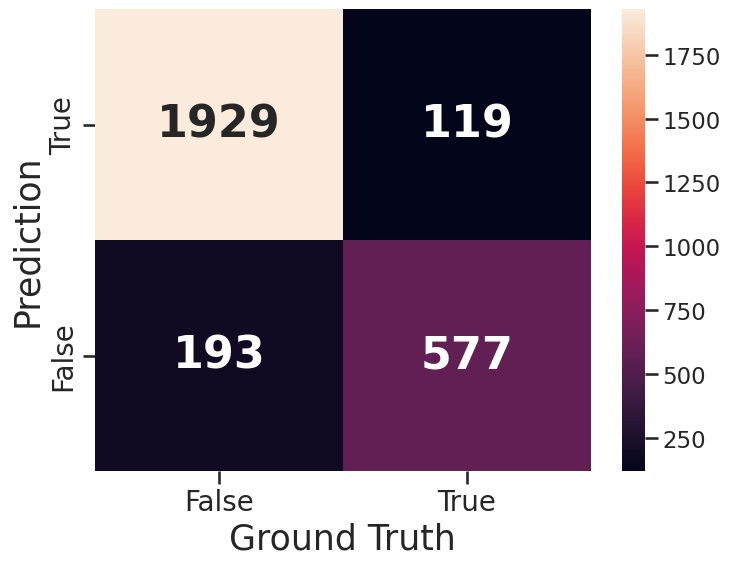

In [35]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, f1_score

df = pd.read_csv("data/churndata_processed.csv")

df_uniques = pd.DataFrame([[i, len(df[i].unique())] for i in df.columns], columns=['Variable', 'Unique Values']).set_index('Variable')
categorical_variables = list(df_uniques[(6 >= df_uniques['Unique Values']) & (df_uniques['Unique Values'] > 2)].index)
binary_variables = list(df_uniques[df_uniques['Unique Values'] == 2].index)
ordinal_variables = ['contract', 'satisfaction']
ordinal_variables.append('months')
numeric_variables = list(set(df.columns) - set(ordinal_variables) - set(categorical_variables) - set(binary_variables))

lb, le = LabelBinarizer(), LabelEncoder()
for column in ordinal_variables:
    df[column] = le.fit_transform(df[column])
for column in binary_variables:
    df[column] = lb.fit_transform(df[column])

categorical_variables = list(set(categorical_variables) - set(ordinal_variables))
df = pd.get_dummies(df, columns = categorical_variables, drop_first=True)

# Set up X and y variables
y, X = df['churn_value'], df.drop(columns='churn_value')

# Split the data into training and test samples
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)


# 1. Define the Pipeline steps
# Format: ('step_name', transformer/estimator)
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier())
])

# 2. Define the parameter grid
# Note the prefix 'knn__' — this tells GridSearchCV to pass these parameters to the 'knn' step
param_grid = {
    'knn__n_neighbors': np.arange(1, 40, 2),
    'knn__weights': ['uniform', 'distance'] # You can test other hyperparameters too!
}

# 3. Wrap the pipeline inside GridSearchCV
knn_cv = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)

# 4. Fit the grid search on raw training data
knn_cv.fit(X_train, y_train)

# 5. Extract the best model and parameters
print(f"Best Parameters: {knn_cv.best_params_}")
print(f"Best CV F1 Score: {round(knn_cv.best_score_, 4)}")

# 6. Predict on test data (it scales X_test automatically using training parameters!)
y_pred = knn_cv.predict(X_test)

# Preciision, recall, f-score from the multi-class support function
print(classification_report(y_test, y_pred))
print('Accuracy score: ', round(accuracy_score(y_test, y_pred), 2))
print('F1 Score: ', round(f1_score(y_test, y_pred), 2))


# Plot confusion matrix
sns.set_palette(sns.color_palette())
_, ax = plt.subplots(figsize=(8,6))
ax = sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', annot_kws={"size": 32, "weight": "bold"})  
labels = ['False', 'True']
ax.set_xticklabels(labels, fontsize=20);
ax.set_yticklabels(labels[::-1], fontsize=20);
ax.set_ylabel('Prediction', fontsize=25);
ax.set_xlabel('Ground Truth', fontsize=25)
